In [1]:
import json
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import xgboost as xgb

# ---------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------
DATA_PATH = Path(
    "./preprocessed_datasets/"
    "dataset_alpha_0.1_full_binarytarget_win-24_thresh-15_both_dynamic-False.parquet"
)


TARGET_COL = "target"
TIME_COL = "timestamp"

TEST_FRAC = 0.30
VAL_FRAC = 0.15

df = pd.read_parquet(DATA_PATH)

# Match your original pipeline where timestamp comes from the index.
# If your parquet already has a timestamp column and you prefer it,
# replace this line with: df[TIME_COL] = pd.to_datetime(df[TIME_COL])
df[TIME_COL] = df.index

# Recreate lag features
for k in range(1, 8):
    df[f"depeg_bps_lag{k}h"] = df["depeg_bps"].shift(k)

df = df.dropna().copy()

df[TIME_COL] = pd.to_datetime(df[TIME_COL])
df = df.sort_values(TIME_COL).reset_index(drop=True)

if TARGET_COL not in df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found in dataset.")

FEATURES = [c for c in df.columns if c not in [TIME_COL, TARGET_COL]]

X = df[FEATURES].copy()
y = df[TARGET_COL].astype(int).copy()

# Convert bool columns to int
bool_cols = X.select_dtypes(include=["bool"]).columns.tolist()
if bool_cols:
    X[bool_cols] = X[bool_cols].astype(int)

# Ensure numeric-only input for XGBoost/TreeHFD
non_numeric_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_cols:
    raise ValueError(
        "XGBoost/TreeHFD require numeric features. "
        f"Non-numeric columns found: {non_numeric_cols}"
    )

print(f"Loaded dataset: {DATA_PATH}")
print(f"Rows after lag/dropna: {len(df):,}")
print(f"Number of features: {len(FEATURES):,}")
print("Target distribution:")
print(y.value_counts().sort_index())

Loaded dataset: preprocessed_datasets/dataset_alpha_0.1_full_binarytarget_win-24_thresh-15_both_dynamic-False.parquet
Rows after lag/dropna: 38,038
Number of features: 105
Target distribution:
target
0    35811
1     2227
Name: count, dtype: int64


In [2]:
import matplotlib.pyplot as plt

import shap

# ---------------------------------------------------------------------
# Load trained Random Forest artifacts
# ---------------------------------------------------------------------
RUN_DIR = Path("./lightning_logs/cv_model_comparison_2026-05-25_full_retraining/random_forest_alpha_0.1_fullfeatures_top2_cv_auc")
MODEL_PATH = RUN_DIR / "artifacts/models/model.joblib"
SCALER_PATH = RUN_DIR / "artifacts/models/preprocess_scaler.joblib"
SIGNATURE_PATH = RUN_DIR / "artifacts/models/signature.json"

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model file not found: {MODEL_PATH}")
if not SIGNATURE_PATH.exists():
    raise FileNotFoundError(f"Signature file not found: {SIGNATURE_PATH}")

with open(SIGNATURE_PATH, "r", encoding="utf-8") as f:
    signature = json.load(f)

model_features = signature["input_columns"]
missing_features = [c for c in model_features if c not in X.columns]
if missing_features:
    raise ValueError(
        "Current dataset is missing features required by the saved model: "
        f"{missing_features[:10]}{'...' if len(missing_features) > 10 else ''}"
    )

X_model = X[model_features].copy()

model = joblib.load(MODEL_PATH)
print(f"Loaded model from: {MODEL_PATH}")
print(f"Model type: {type(model).__name__}")
print(f"Feature count used by model: {len(model_features)}")

# ---------------------------------------------------------------------
# Apply preprocessing used during training (if available)
# ---------------------------------------------------------------------
if SCALER_PATH.exists():
    scaler = joblib.load(SCALER_PATH)
    X_model_proc = pd.DataFrame(
        scaler.transform(X_model),
        columns=model_features,
        index=X_model.index,
    )
    print(f"Applied scaler from: {SCALER_PATH}")
else:
    scaler = None
    X_model_proc = X_model
    print("No scaler artifact found. Using raw feature matrix.")

Loaded model from: lightning_logs/cv_model_comparison_2026-05-25_full_retraining/random_forest_alpha_0.1_fullfeatures_top2_cv_auc/artifacts/models/model.joblib
Model type: RandomForestClassifier
Feature count used by model: 105
Applied scaler from: lightning_logs/cv_model_comparison_2026-05-25_full_retraining/random_forest_alpha_0.1_fullfeatures_top2_cv_auc/artifacts/models/preprocess_scaler.joblib


In [3]:
X_test = X_model_proc.iloc[-11411:]

In [18]:
thresh = 0.26206363772145314
y_pred_proba = model.predict_proba(X_test)[:, 1]

In [10]:
explainer = shap.TreeExplainer(model, model_output="raw")

In [ ]:
svint = explainer.shap_interaction_values(X_test)

In [5]:
sv = explainer(X_test)

100%|===================| 22796/22822 [10:40<00:00]        

In [ ]:
pkl.dump(sv, open("shap_values.pkl", "wb"))

In [4]:
import pickle as pkl 
sv = pkl.load(open("./shap_values.pkl", "rb"))

In [5]:
sv.feature_names

['tvlUSD_100',
 'net_amountUSD_100',
 'net_amount0',
 'swap_count_100',
 'swap_count_500',
 'net_amountUSD_500',
 'tvlUSD_500',
 'supplied_USD_usdt',
 'utilisation_rate_usdt',
 'supplied_USD_usdc',
 'utilisation_rate_usdc',
 'liquidation_USD',
 'totalValueLockedUSD',
 'hourlyVolumeUSD',
 'w_USDC',
 'w_USDT',
 'curve_entropy',
 'eth_price_usd',
 'eth_SMA_1200',
 'eth_EMA_4800',
 'eth_RSI_24',
 'eth_ATR_24',
 'eth_vol_168',
 'btc_price_usd',
 'btc_SMA_1200',
 'btc_EMA_4800',
 'btc_RSI_24',
 'btc_ATR_24',
 'btc_vol_168',
 'usd_index',
 'fx_volatility',
 'fear_greed_index',
 'Gegenbauer_0.1_deg0',
 'Gegenbauer_0.1_deg1',
 'Gegenbauer_0.1_deg2',
 'Gegenbauer_0.1_deg3',
 'Gegenbauer_0.1_deg4',
 'Gegenbauer_0.1_deg5',
 'Gegenbauer_0.1_deg6',
 'Gegenbauer_0.1_deg7',
 'E_total',
 'E_shape',
 'E_odd',
 'E_even',
 'odd_ratio',
 'even_ratio',
 'odd_to_even_ratio',
 'E_low',
 'E_mid',
 'E_high',
 'low_ratio',
 'mid_ratio',
 'high_ratio',
 'E_shape_logret',
 'E_odd_logret',
 'E_even_logret',
 'odd_r

In [32]:
sv[:,:,1].values.std(0)

array([4.41913024e-04, 9.52328284e-04, 8.49403322e-05, 9.38865930e-03,
       4.50258179e-04, 2.00651865e-04, 2.35453053e-03, 0.00000000e+00,
       9.37299184e-04, 1.23018689e-03, 1.09031216e-03, 2.02266132e-04,
       9.24143583e-04, 1.35735070e-03, 4.16114872e-03, 5.36945482e-03,
       2.83510095e-02, 1.07909208e-02, 3.50410739e-03, 2.11317962e-03,
       2.86059760e-03, 4.38950222e-03, 1.18812313e-03, 2.06626178e-03,
       0.00000000e+00, 0.00000000e+00, 1.17959181e-03, 8.20073541e-03,
       3.44581090e-03, 4.62691830e-03, 2.12353233e-03, 1.39286746e-03,
       3.22371656e-04, 1.00923184e-03, 9.23764712e-04, 4.35214695e-04,
       9.97011998e-04, 6.86912950e-04, 3.00715027e-04, 1.30028300e-03,
       3.63641823e-04, 3.31753860e-04, 5.34953597e-04, 3.14423987e-04,
       5.54508983e-04, 4.34105150e-04, 5.44178710e-04, 3.90201528e-04,
       1.68915646e-03, 5.80732671e-04, 8.94051259e-04, 9.36542967e-04,
       3.79595991e-04, 3.76645947e-05, 6.74397195e-05, 7.23569772e-05,
      

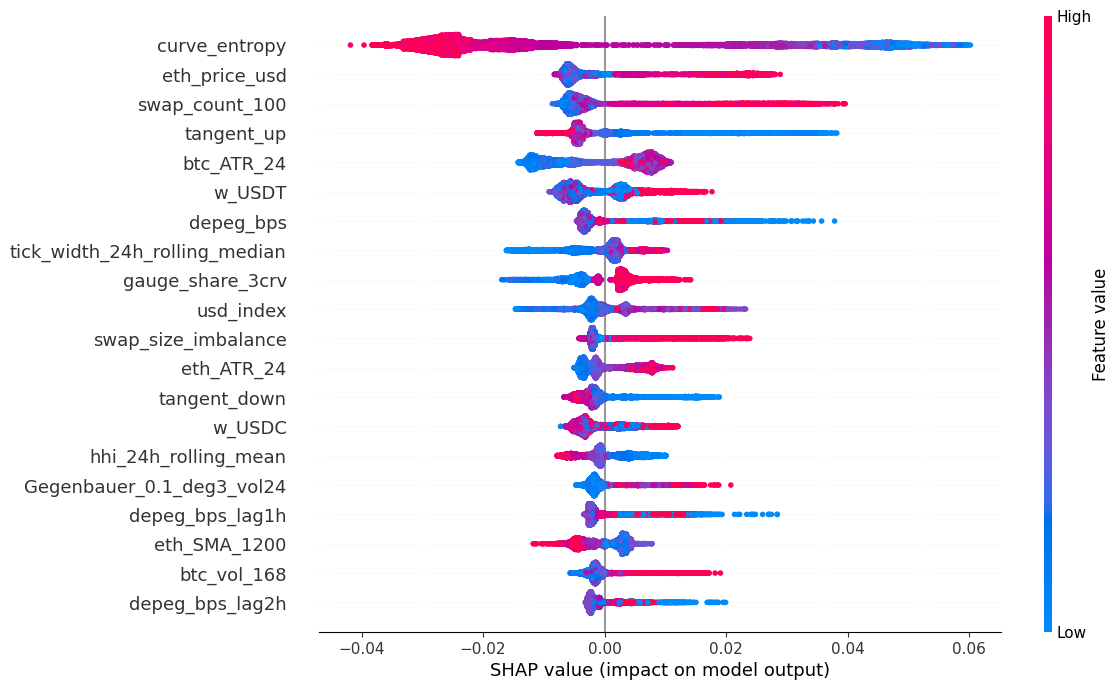

In [43]:
shap.plots.beeswarm(sv[:,:,1], max_display=20, group_remaining_features=False, order=np.argsort(sv[:,:,1].values.std(0))[::-1], plot_size=(11,8), show = False)
plt.savefig("shap_beeswarm.png", dpi=300, bbox_inches="tight", transparent=True)

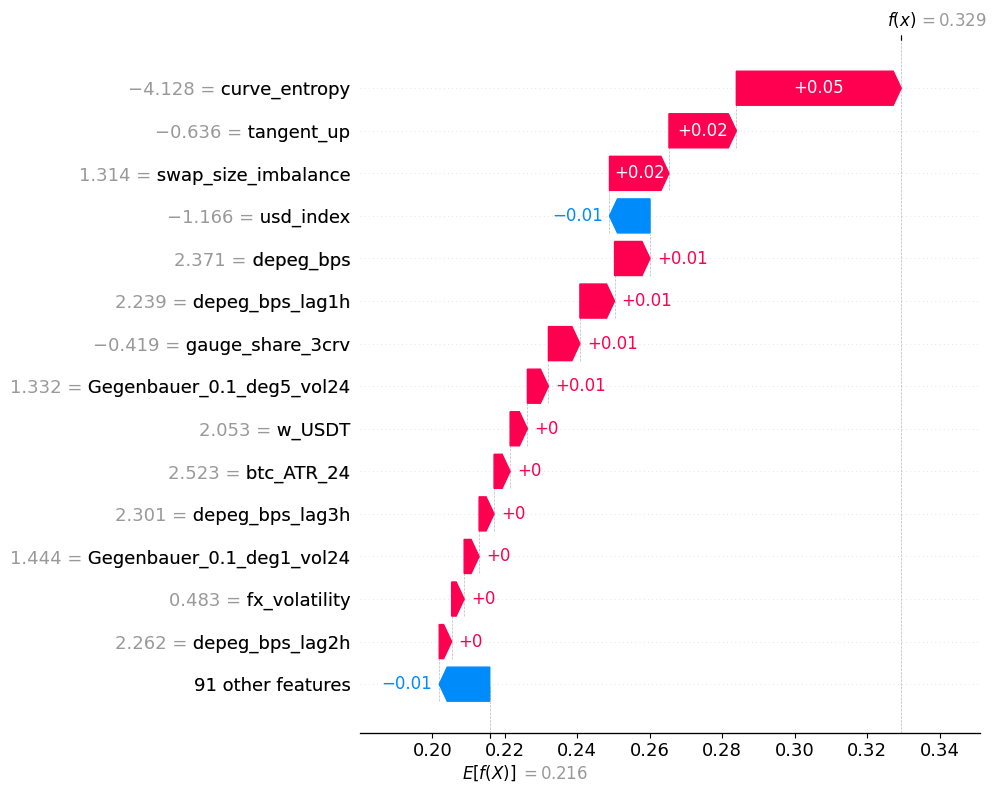

In [8]:
plt.figure(figsize=(8, 6))
shap.plots.waterfall(sv[9074, :, 1], max_display=15, show=False)
plt.savefig("shap_waterfall_9074.png", dpi=300, bbox_inches="tight", transparent=True)

In [9]:
plt.figure(figsize=(8, 6))
shap.plots.waterfall(sv[9215, :, 1], max_display=15, show=False)
plt.savefig("shap_waterfall_9215.png", dpi=300, bbox_inches="tight", transparent=True)

In [10]:
plt.figure(figsize=(8, 6))
shap.plots.waterfall(sv[6412, :, 1], max_display=15, show=False)
plt.savefig("shap_waterfall_6412.png", dpi=300, bbox_inches="tight", transparent=True)

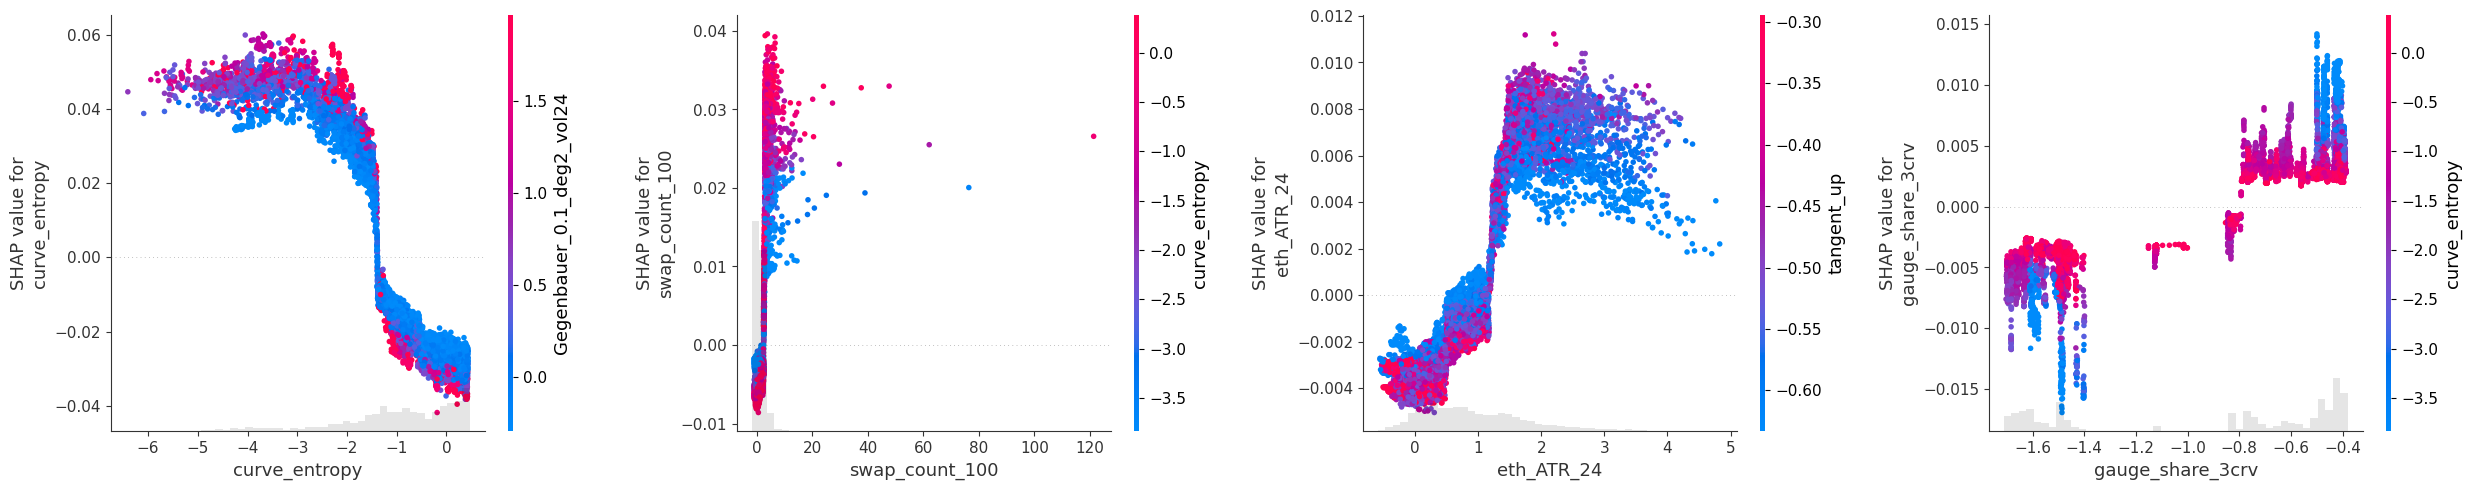

In [6]:
feats = ['curve_entropy', 'swap_count_100', 'eth_ATR_24', 'gauge_share_3crv']
fig, axs = plt.subplots(1, len(feats), figsize = (25, 5))
for i, ax in enumerate(axs):
    shap.plots.scatter(sv[:, feats[i], 1], color = sv[:, :, 1], ax=ax, show = False)
fig.subplots_adjust(left=0.34, right=0.98, top=0.96, bottom=0.05, hspace=0.45)
fig.tight_layout()
plt.savefig('shap_scatter_plots.png', dpi=300, bbox_inches="tight", transparent=True)

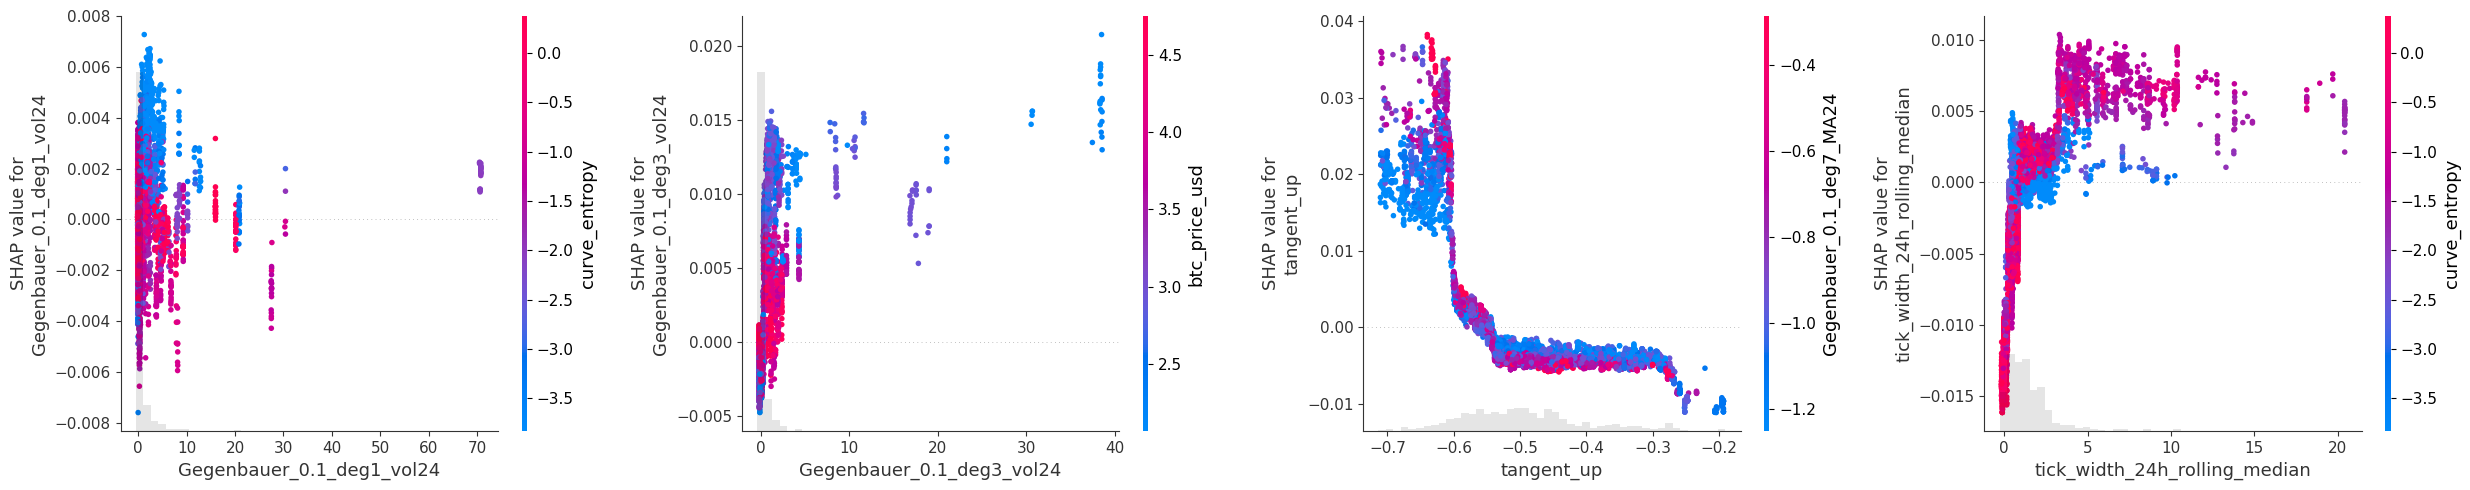

In [7]:
feats = ["Gegenbauer_0.1_deg1_vol24", 'Gegenbauer_0.1_deg3_vol24', 'tangent_up', 'tick_width_24h_rolling_median']
fig, axs = plt.subplots(1, len(feats), figsize = (25, 5))
for i, ax in enumerate(axs):
    shap.plots.scatter(sv[:, feats[i], 1], color = sv[:, :, 1], ax=ax, show = False)
fig.subplots_adjust(left=0.34, right=0.98, top=0.96, bottom=0.05, hspace=0.45)
fig.tight_layout()
plt.savefig('shap_scatter_plots_volatility.png', dpi=300, bbox_inches="tight", transparent=True)

<Figure size 800x600 with 0 Axes>

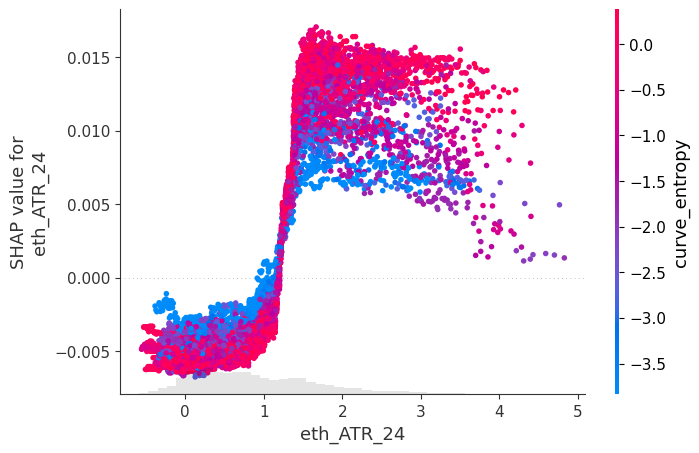

In [ ]:
plt.figure(figsize=(8, 6))
shap.plots.scatter(sv[:, "eth_ATR_24", 1], color = sv[:, :, 1])

<Figure size 800x600 with 0 Axes>

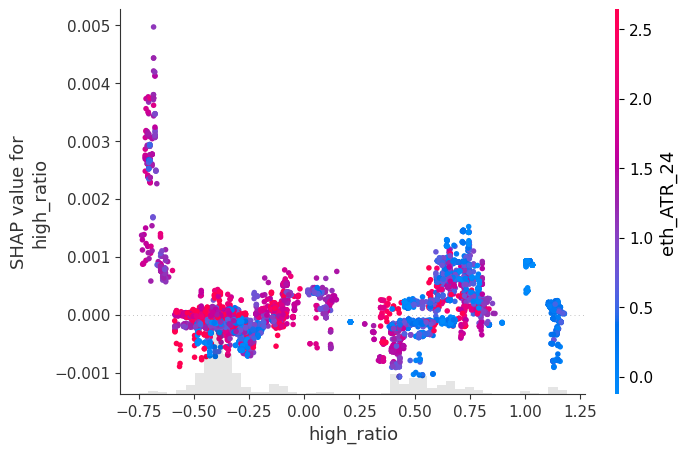

In [72]:
plt.figure(figsize=(8, 6))
shap.plots.scatter(sv[:, "high_ratio", 1], color = sv[:, :, 1])

<Figure size 800x600 with 0 Axes>

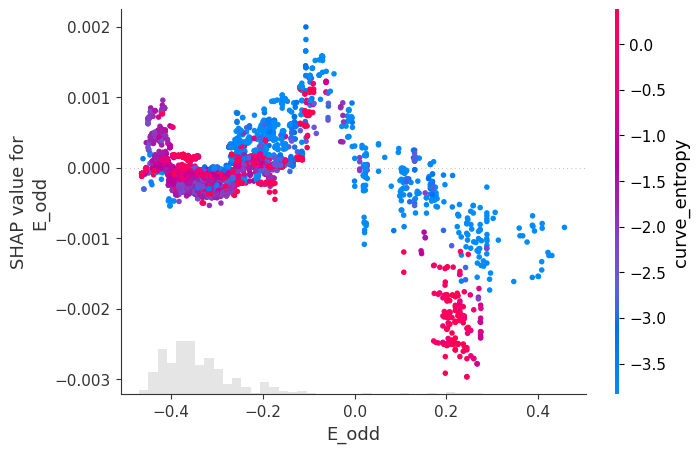

In [46]:
plt.figure(figsize=(8, 6))
shap.plots.scatter(sv[:, "E_odd", 1], color = sv[:, :, 1])

Feature groups:

Uniswap V3 liquidity-curve shape (62 features)
['tvlUSD_100', 'tvlUSD_500', 'Gegenbauer_0.1_deg0', 'Gegenbauer_0.1_deg1', 'Gegenbauer_0.1_deg2', 'Gegenbauer_0.1_deg3', 'Gegenbauer_0.1_deg4', 'Gegenbauer_0.1_deg5', 'Gegenbauer_0.1_deg6', 'Gegenbauer_0.1_deg7', 'E_total', 'E_shape', 'E_odd', 'E_even', 'odd_ratio', 'even_ratio', 'odd_to_even_ratio', 'E_low', 'E_mid', 'E_high', 'low_ratio', 'mid_ratio', 'high_ratio', 'E_shape_logret', 'E_odd_logret', 'E_even_logret', 'odd_ratio_logret', 'even_ratio_logret', 'odd_to_even_ratio_logret', 'E_low_logret', 'E_mid_logret', 'E_high_logret', 'low_ratio_logret', 'mid_ratio_logret', 'high_ratio_logret', 'Gegenbauer_0.1_deg0_MA24', 'Gegenbauer_0.1_deg0_logret', 'Gegenbauer_0.1_deg0_vol24', 'Gegenbauer_0.1_deg1_MA24', 'Gegenbauer_0.1_deg1_logret', 'Gegenbauer_0.1_deg1_vol24', 'Gegenbauer_0.1_deg2_MA24', 'Gegenbauer_0.1_deg2_logret', 'Gegenbauer_0.1_deg2_vol24', 'Gegenbauer_0.1_deg3_MA24', 'Gegenbauer_0.1_deg3_logret', 'Gegenbauer_0.1_d

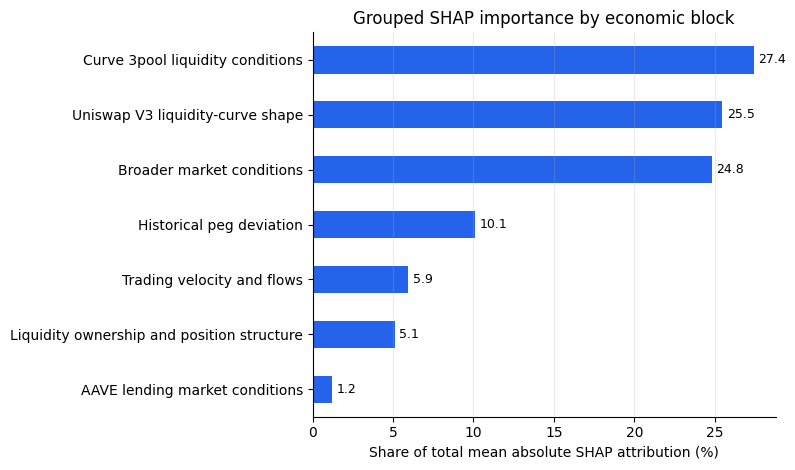

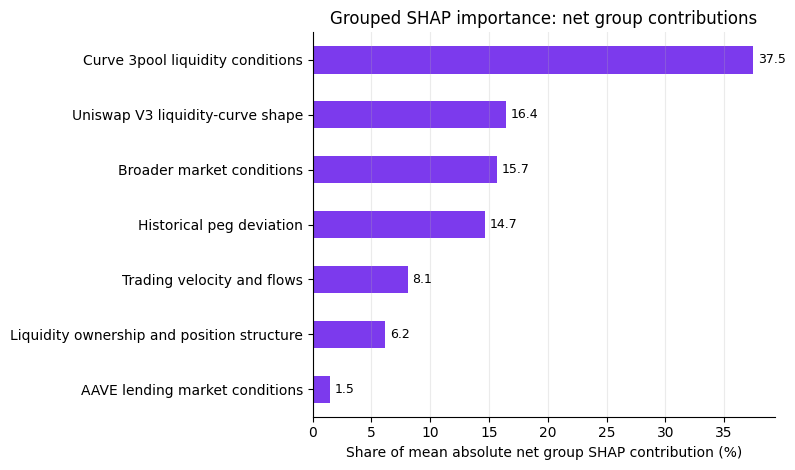

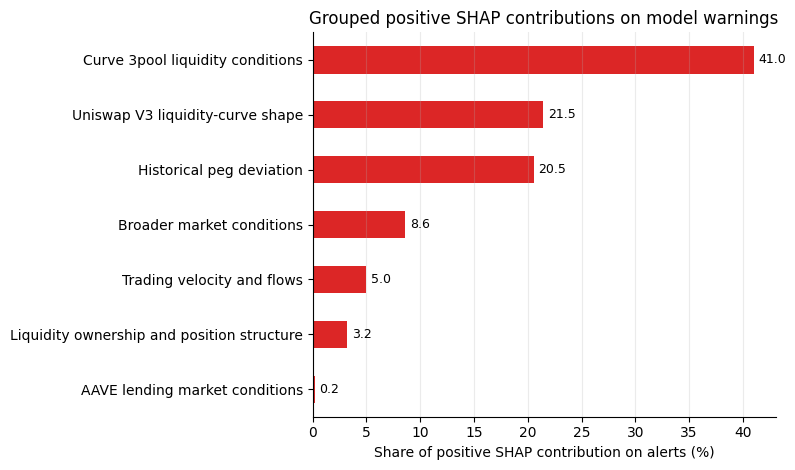

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import OrderedDict


# ---------------------------------------------------------------------
# 1. Extract SHAP matrix robustly
# ---------------------------------------------------------------------

def get_shap_matrix(sv, positive_class=1):
    """
    Return SHAP values as an array of shape (n_samples, n_features).

    Handles:
    - shap.Explanation with values shape (n, p)
    - shap.Explanation with values shape (n, p, K)
    - raw numpy arrays with same shapes
    """
    values = sv.values if hasattr(sv, "values") else sv
    values = np.asarray(values)

    if values.ndim == 2:
        return values

    if values.ndim == 3:
        # Common case for classifiers: (n_samples, n_features, n_classes)
        return values[:, :, positive_class]

    raise ValueError(f"Unexpected SHAP values shape: {values.shape}")


features = list(sv.feature_names)
shap_mat = get_shap_matrix(sv, positive_class=1)

assert shap_mat.shape[1] == len(features), (
    shap_mat.shape, len(features)
)

shap_df = pd.DataFrame(shap_mat, columns=features)


# ---------------------------------------------------------------------
# 2. Define feature groups
# ---------------------------------------------------------------------

def has_any_prefix(x, prefixes):
    return any(x.startswith(p) for p in prefixes)

def has_any_substring(x, substrings):
    return any(s in x for s in substrings)


feature_groups = OrderedDict()

# Main Uniswap V3 USDC/USDT liquidity-curve shape.
# Includes Gegenbauer coefficients, energy features derived from the
# decomposition, ratios, tangents of swap-size impact curve, and swap-size
# imbalance.
feature_groups["Uniswap V3 liquidity-curve shape"] = [
    f for f in features
    if (
        f.startswith("Gegenbauer_")
        or f.startswith("E_")
        or ("ratio" in f)
        or f in [
            "tangent_up",
            "tangent_down",
            "swap_size_imbalance",
            "tvlUSD_100",
        "tvlUSD_500",
        ]
    )
]

# Curve 3pool broad stablecoin liquidity conditions.
feature_groups["Curve 3pool liquidity conditions"] = [
    f for f in [
        "w_USDC",
        "w_USDT",
        "curve_entropy",
        "gauge_share_3crv",
        "totalValueLockedUSD",
    ]
    if f in features
]

# Broader market conditions: ETH/BTC technical indicators, dollar index,
# FX volatility, sentiment.
feature_groups["Broader market conditions"] = [
    f for f in features
    if (
        f.startswith("eth_")
        or f.startswith("btc_")
        or f in [
            "usd_index",
            "fx_volatility",
            "fear_greed_index",
        ]
    )
]

# Historical stablecoin peg deviation.
feature_groups["Historical peg deviation"] = [
    f for f in features
    if f == "depeg_bps" or f.startswith("depeg_bps_lag")
]

# Liquidity ownership, concentration, and position structure.
# hhi_24h_rolling_mean: concentration of liquidity ownership
# tick_width_24h_rolling_median: typical width of in-range NFPM positions
# n_in_range_log_return: change in number of in-range positions
# weighted_mean_age_hours: age structure of liquidity positions
# tvlUSD_*: stock of liquidity in Uniswap fee-tier pools
feature_groups["Liquidity ownership and position structure"] = [
    f for f in [
        "hhi_24h_rolling_mean",
        "tick_width_24h_rolling_median",
        "n_in_range_log_return",
        "weighted_mean_age_hours",
        
    ]
    if f in features
]

# Market velocity and flows on Uniswap / aggregate DEX activity.
feature_groups["Trading velocity and flows"] = [
    f for f in [
        "swap_count_100",
        "swap_count_500",
        "net_amountUSD_100",
        "net_amountUSD_500",
        "net_amount0",
        "hourlyVolumeUSD",
    ]
    if f in features
]

# AAVE lending market variables.
feature_groups["AAVE lending market conditions"] = [
    f for f in [
        "supplied_USD_usdt",
        "utilisation_rate_usdt",
        "supplied_USD_usdc",
        "utilisation_rate_usdc",
        "liquidation_USD",
    ]
    if f in features
]


# ---------------------------------------------------------------------
# 3. Clean groups: remove duplicates and collect unassigned features
# ---------------------------------------------------------------------

def clean_feature_groups(feature_groups, features, add_other=True):
    """
    Remove duplicate assignments while preserving dictionary order.
    Add an 'Other' group for unassigned model features.
    """
    features = list(features)
    assigned = set()
    clean_groups = OrderedDict()

    for group_name, cols in feature_groups.items():
        cols_clean = []
        for c in cols:
            if c in features and c not in assigned:
                cols_clean.append(c)
                assigned.add(c)

        if len(cols_clean) > 0:
            clean_groups[group_name] = cols_clean

    unassigned = [f for f in features if f not in assigned]

    if add_other and len(unassigned) > 0:
        clean_groups["Other"] = unassigned

    return clean_groups, unassigned


feature_groups, unassigned = clean_feature_groups(feature_groups, features)

print("Feature groups:")
for group, cols in feature_groups.items():
    print(f"\n{group} ({len(cols)} features)")
    print(cols)

print("\nUnassigned features before adding 'Other':")
print(unassigned)


# ---------------------------------------------------------------------
# 4. Compute grouped SHAP importances
# ---------------------------------------------------------------------

def compute_grouped_shap_importance(
    shap_df,
    feature_groups,
    aggregation="sum_abs",
    mask=None,
    normalize=True,
):
    """
    Compute grouped SHAP importance.

    Parameters
    ----------
    shap_df : pd.DataFrame
        SHAP values, shape (n_samples, n_features).

    feature_groups : dict
        Dictionary mapping group name to list of feature names.

    aggregation : {"sum_abs", "abs_sum", "signed_mean", "positive_mean"}
        - "sum_abs":
            sum_j mean_i |phi_ij| within group.
            Measures total attribution mass of the group.
        - "abs_sum":
            mean_i |sum_j phi_ij| within group.
            Measures net group contribution after cancellation.
        - "signed_mean":
            mean_i sum_j phi_ij.
            Measures average signed contribution.
        - "positive_mean":
            mean_i max(sum_j phi_ij, 0).
            Measures average positive contribution to warning class.

    mask : array-like of bool, optional
        If provided, compute importance only on selected rows,
        e.g. samples where the model triggered an alert.

    normalize : bool
        If True, return percentages summing to 100 for nonnegative
        aggregations.

    Returns
    -------
    importance : pd.Series
        Grouped importance values.
    grouped_contrib : pd.DataFrame
        Additive group-level SHAP contributions, one column per group.
    """
    if mask is not None:
        shap_use = shap_df.loc[mask].copy()
    else:
        shap_use = shap_df.copy()

    grouped_contrib = pd.DataFrame(index=shap_use.index)

    for group, cols in feature_groups.items():
        cols = [c for c in cols if c in shap_use.columns]
        if len(cols) == 0:
            continue
        grouped_contrib[group] = shap_use[cols].sum(axis=1)

    if aggregation == "sum_abs":
        vals = {}
        for group, cols in feature_groups.items():
            cols = [c for c in cols if c in shap_use.columns]
            if len(cols) == 0:
                continue
            vals[group] = shap_use[cols].abs().mean(axis=0).sum()
        importance = pd.Series(vals)

    elif aggregation == "abs_sum":
        importance = grouped_contrib.abs().mean(axis=0)

    elif aggregation == "signed_mean":
        importance = grouped_contrib.mean(axis=0)

    elif aggregation == "positive_mean":
        importance = grouped_contrib.clip(lower=0).mean(axis=0)

    else:
        raise ValueError(
            "aggregation must be one of "
            "{'sum_abs', 'abs_sum', 'signed_mean', 'positive_mean'}"
        )

    importance = importance.sort_values(ascending=True)

    if normalize and aggregation in ["sum_abs", "abs_sum", "positive_mean"]:
        total = importance.sum()
        if total > 0:
            importance = 100 * importance / total

    return importance, grouped_contrib


# ---------------------------------------------------------------------
# 5. Plot helper
# ---------------------------------------------------------------------

def plot_grouped_shap_bar(
    importance,
    title=None,
    xlabel=None,
    figsize=(8, 4.8),
    color="#3B82F6",
    save_path=None,
):
    fig, ax = plt.subplots(figsize=figsize)

    importance.plot(kind="barh", ax=ax, color=color)

    ax.set_title(title or "Grouped SHAP importance")
    ax.set_xlabel(xlabel or "Share of grouped SHAP importance (%)")
    ax.set_ylabel("")

    # Add value labels
    xlim = ax.get_xlim()
    width = xlim[1] - xlim[0]
    for i, v in enumerate(importance.values):
        ax.text(
            v + 0.01 * width,
            i,
            f"{v:.1f}",
            va="center",
            fontsize=9,
        )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", alpha=0.25)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, ax


# ---------------------------------------------------------------------
# 6. Main grouped plot: total attribution mass by economic group
# ---------------------------------------------------------------------

importance_sum_abs, grouped_contrib = compute_grouped_shap_importance(
    shap_df=shap_df,
    feature_groups=feature_groups,
    aggregation="sum_abs",
    mask=None,
    normalize=True,
)

fig, ax = plot_grouped_shap_bar(
    importance_sum_abs,
    title="Grouped SHAP importance by economic block",
    xlabel="Share of total mean absolute SHAP attribution (%)",
    color="#2563EB",
    save_path="shap_grouped_importance_sum_abs.png",
)

plt.show()


# ---------------------------------------------------------------------
# 7. Alternative plot: net group contribution after within-group cancellation
# ---------------------------------------------------------------------

importance_abs_sum, grouped_contrib = compute_grouped_shap_importance(
    shap_df=shap_df,
    feature_groups=feature_groups,
    aggregation="abs_sum",
    mask=None,
    normalize=True,
)

fig, ax = plot_grouped_shap_bar(
    importance_abs_sum,
    title="Grouped SHAP importance: net group contributions",
    xlabel="Share of mean absolute net group SHAP contribution (%)",
    color="#7C3AED",
    save_path="shap_grouped_importance_abs_sum.png",
)

plt.show()


# ---------------------------------------------------------------------
# 8. Optional: positive contribution to warnings only
# ---------------------------------------------------------------------
# If you have a warning mask, for example:
#

# or:
# warning_mask = pred_proba_test[:, 1] >= warning_threshold
#
# then compute group importance only on warning observations.

# Example placeholder:
# warning_mask = pred_proba_test[:, 1] >= warning_threshold

warning_mask = y_pred_proba >= thresh
importance_pos_alerts, grouped_contrib_alerts = compute_grouped_shap_importance(
    shap_df=shap_df,
    feature_groups=feature_groups,
    aggregation="positive_mean",
    mask=warning_mask,
    normalize=True,
)

fig, ax = plot_grouped_shap_bar(
    importance_pos_alerts,
    title="Grouped positive SHAP contributions on model warnings",
    xlabel="Share of positive SHAP contribution on alerts (%)",
    color="#DC2626",
    save_path="shap_grouped_positive_alerts.png",
)

plt.show()